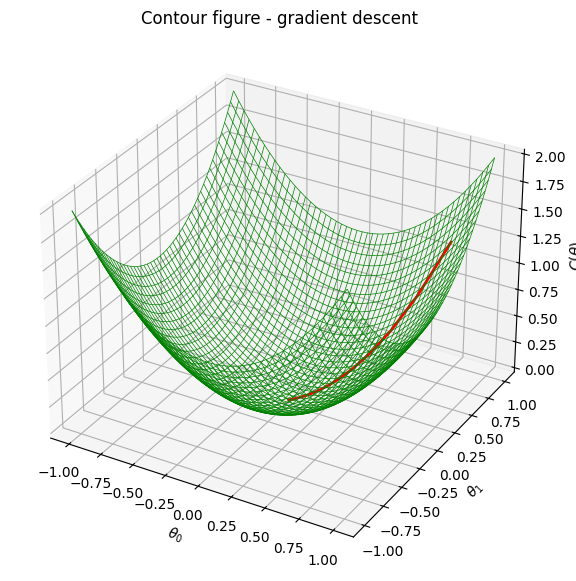

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Cost function J(θ0, θ1)
def cost(theta0, theta1):
    return theta0**2 + theta1**2

# Gradient of the cost function
def grad(theta0, theta1):
    return np.array([2*theta0, 2*theta1])

# Generate meshgrid for 3D surface
t0 = np.linspace(-1, 1, 50)
t1 = np.linspace(-1, 1, 50)
T0, T1 = np.meshgrid(t0, t1)
Z = cost(T0, T1)

# Gradient descent settings
alpha = 0.1
theta = np.array([0.8, 0.8])   # starting point
path = [theta.copy()]

for _ in range(20):
    theta = theta - alpha * grad(theta[0], theta[1])
    path.append(theta.copy())

path = np.array(path)
path_z = cost(path[:,0], path[:,1])

# Plotting
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_wireframe(T0, T1, Z, color='green', linewidth=0.5)
ax.plot(path[:,0], path[:,1], path_z, color='red', linewidth=2)

ax.set_title("Contour figure - gradient descent")
ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')
ax.set_zlabel(r'$C(\theta)$')

plt.show()


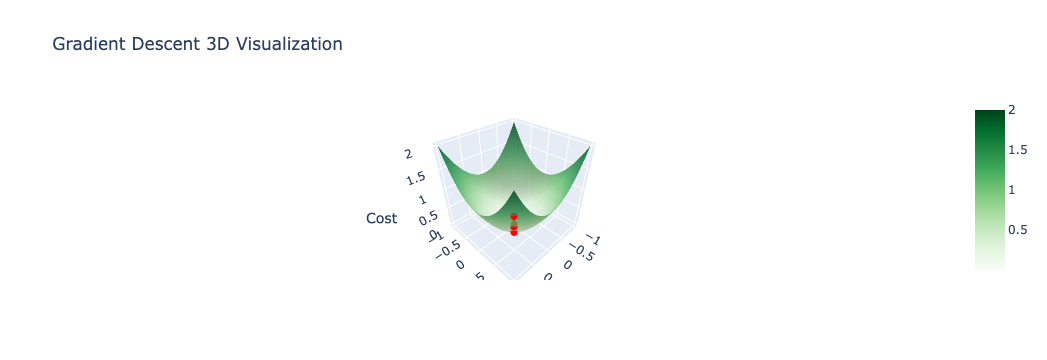

In [7]:
import numpy as np
import plotly.graph_objects as go

# Cost function
def cost(theta0, theta1):
    return theta0**2 + theta1**2

# Gradient
def grad(theta0, theta1):
    return np.array([2*theta0, 2*theta1])

# Surface
t0 = np.linspace(-1, 1, 50)
t1 = np.linspace(-1, 1, 50)
T0, T1 = np.meshgrid(t0, t1)
Z = cost(T0, T1)

# Gradient descent
alpha = 0.1
theta = np.array([0.8, 0.8])
path = [theta.copy()]

for _ in range(20):
    theta = theta - alpha * grad(theta[0], theta[1])
    path.append(theta.copy())

path = np.array(path)
path_z = cost(path[:, 0], path[:, 1])

# Plotly Figure
fig = go.Figure()

# Add surface
fig.add_trace(go.Surface(x=T0, y=T1, z=Z, colorscale='Greens', opacity=0.8))

# Add descent path
fig.add_trace(
    go.Scatter3d(
        x=path[:,0], y=path[:,1], z=path_z,
        mode='lines+markers',
        line=dict(width=5, color='red'),
        marker=dict(size=4, color='red')
    )
)

fig.update_layout(
    title="Gradient Descent 3D Visualization",
    scene=dict(
        xaxis_title="θ0",
        yaxis_title="θ1",
        zaxis_title="Cost"
    )
)

fig.show()
